# Modeling v2: 30-Day Readmission Prediction

Models: Logistic Regression, Random Forest, XGBoost. Includes calibration curves, ROC curves, and fairness audit.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
from datetime import datetime
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report,
    roc_curve, precision_score, recall_score, f1_score
)
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

## Section 1: Load Data

In [32]:
X_train = pd.read_parquet('../outputs/X_train.parquet')
X_test = pd.read_parquet('../outputs/X_test.parquet')
y_train = pd.read_csv('../outputs/y_train.csv').squeeze('columns')
y_test = pd.read_csv('../outputs/y_test.csv').squeeze('columns')

print('Shapes:')
print('  X_train:', X_train.shape)
print('  X_test: ', X_test.shape)
print('  y_train:', y_train.shape)
print('  y_test: ', y_test.shape)

print()
print('X_train head:')
print(X_train.head())
print()
print('X_train dtypes (first 5):')
print(X_train.dtypes.head())

print()
print('y_train head:')
print(y_train.head())
print('y_train dtype:', y_train.dtype)
print()
print('y_test head:')
print(y_test.head())
print('y_test dtype:', y_test.dtype)

print()
unique_train = sorted(y_train.unique())
unique_test = sorted(y_test.unique())
print('y_train unique values:', unique_train)
print('y_test unique values: ', unique_test)
assert set(unique_train) <= {0, 1}, 'y_train contains non-binary values'
assert set(unique_test) <= {0, 1}, 'y_test contains non-binary values'
print('Label check passed: binary (0/1) confirmed.')

print()
print('Class balance in y_train:')
print(y_train.value_counts(normalize=True))

Shapes:
  X_train: (19110, 452)
  X_test:  (4771, 452)
  y_train: (19110,)
  y_test:  (4771,)

X_train head:
   age_at_admission  los_days  came_via_ed  prior_admissions_count  10     \
0         -0.479378  0.289850    -1.489563               -0.551507      0   
1         -0.426536 -0.635264    -1.489563               -0.361839      0   
2          0.207565 -0.635264     0.671338               -0.551507      0   
3         -1.483372  0.104827     0.671338               -0.551507      0   
4         -1.324847  2.880167     0.671338               -0.361839      0   

   100    101    102    103    104    ...  marital_status_SINGLE  \
0      0      0      0      0      0  ...                  False   
1      0      0      0      0      0  ...                  False   
2      0      0      0      0      0  ...                  False   
3      0      0      0      0      0  ...                   True   
4      0      0      0      0      0  ...                   True   

   marital_status_W

## Section 2: Baseline - Logistic Regression

In [33]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)

lr_probs = lr.predict_proba(X_test)[:, 1]
lr_preds = lr.predict(X_test)

lr_auc = roc_auc_score(y_test, lr_probs)
lr_acc = accuracy_score(y_test, lr_preds)

print('Logistic Regression')
print(f'  ROC-AUC: {lr_auc:.4f}')
print(f'  Accuracy: {lr_acc:.4f}')
print()
print(classification_report(y_test, lr_preds, target_names=['Not Readmitted', 'Readmitted']))

joblib.dump(lr, '../outputs/lr_model.pkl')
print('Saved: ../outputs/lr_model.pkl')

Logistic Regression
  ROC-AUC: 0.6996
  Accuracy: 0.7017

                precision    recall  f1-score   support

Not Readmitted       0.87      0.73      0.80      3826
    Readmitted       0.35      0.57      0.43       945

      accuracy                           0.70      4771
     macro avg       0.61      0.65      0.61      4771
  weighted avg       0.77      0.70      0.73      4771

Saved: ../outputs/lr_model.pkl


## Section 3: Random Forest

In [34]:
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]
rf_preds = rf.predict(X_test)

rf_auc = roc_auc_score(y_test, rf_probs)
rf_acc = accuracy_score(y_test, rf_preds)

print('Random Forest')
print(f'  ROC-AUC: {rf_auc:.4f}')
print(f'  Accuracy: {rf_acc:.4f}')
print()
print(classification_report(y_test, rf_preds, target_names=['Not Readmitted', 'Readmitted']))

joblib.dump(rf, '../outputs/rf_model.pkl')
print('Saved: ../outputs/rf_model.pkl')

Random Forest
  ROC-AUC: 0.7493
  Accuracy: 0.8026

                precision    recall  f1-score   support

Not Readmitted       0.80      1.00      0.89      3826
    Readmitted       0.71      0.01      0.01       945

      accuracy                           0.80      4771
     macro avg       0.76      0.50      0.45      4771
  weighted avg       0.79      0.80      0.72      4771

Saved: ../outputs/rf_model.pkl


## Section 4: XGBoost

In [35]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'Negative count: {neg_count}')
print(f'Positive count: {pos_count}')
print(f'scale_pos_weight: {scale_pos_weight:.4f}')

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)

xgb_probs = xgb.predict_proba(X_test)[:, 1]
xgb_preds = xgb.predict(X_test)

xgb_auc = roc_auc_score(y_test, xgb_probs)
xgb_acc = accuracy_score(y_test, xgb_preds)

print()
print('XGBoost')
print(f'  ROC-AUC: {xgb_auc:.4f}')
print(f'  Accuracy: {xgb_acc:.4f}')
print()
print(classification_report(y_test, xgb_preds, target_names=['Not Readmitted', 'Readmitted']))

joblib.dump(xgb, '../outputs/xgb_model.pkl')
print('Saved: ../outputs/xgb_model.pkl')

Negative count: 15336
Positive count: 3774
scale_pos_weight: 4.0636

XGBoost
  ROC-AUC: 0.7513
  Accuracy: 0.7426

                precision    recall  f1-score   support

Not Readmitted       0.88      0.79      0.83      3826
    Readmitted       0.39      0.55      0.46       945

      accuracy                           0.74      4771
     macro avg       0.64      0.67      0.65      4771
  weighted avg       0.78      0.74      0.76      4771

Saved: ../outputs/xgb_model.pkl


## Section 5: Model Comparison Table

In [36]:
def build_metrics_row(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'ROC_AUC': round(roc_auc_score(y_true, y_prob), 4),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1': round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

results = [
    build_metrics_row('LR', y_test, lr_preds, lr_probs),
    build_metrics_row('RF', y_test, rf_preds, rf_probs),
    build_metrics_row('XGB', y_test, xgb_preds, xgb_probs),
]

comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

best_row = comparison_df.loc[comparison_df['ROC_AUC'].idxmax()]
best_model_name = best_row['Model']
best_model_auc = best_row['ROC_AUC']
print()
print(f'Best model by ROC-AUC: {best_model_name}')

model_map = {
    'LR': (lr, lr_probs),
    'RF': (rf, rf_probs),
    'XGB': (xgb, xgb_probs),
}
best_model_obj, best_probs = model_map[best_model_name]

Model  ROC_AUC  Accuracy  Precision  Recall     F1
   LR   0.6996    0.7017     0.3460  0.5683 0.4301
   RF   0.7493    0.8026     0.7143  0.0053 0.0105
  XGB   0.7513    0.7426     0.3934  0.5524 0.4595

Best model by ROC-AUC: XGB


## Section 6: Calibration Curves

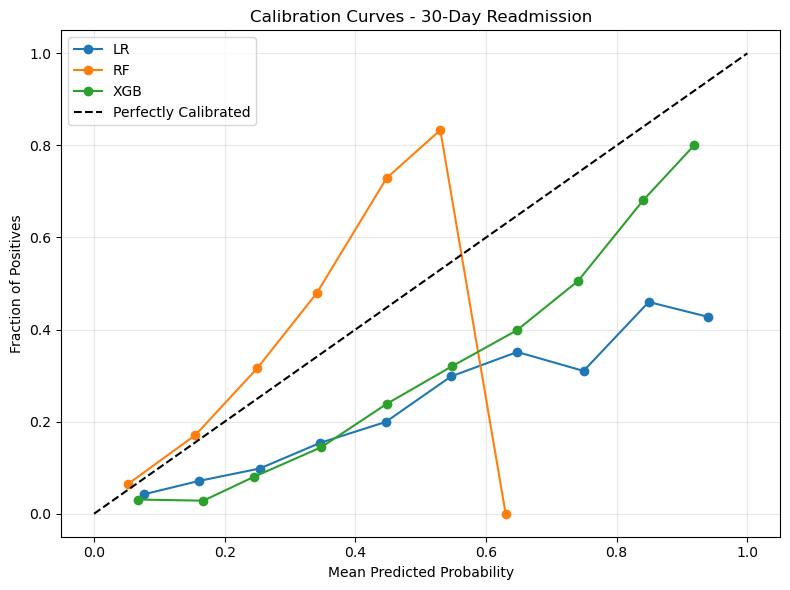

Saved: ../outputs/calibration_curves.png


In [37]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, probs in [('LR', lr_probs), ('RF', rf_probs), ('XGB', xgb_probs)]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker='o', label=name)

ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves - 30-Day Readmission')
ax.legend()
ax.grid(True, alpha=0.3)
# Calibration matters in healthcare: predicted probabilities are used for clinical decision making.
plt.tight_layout()
plt.savefig('../outputs/calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../outputs/calibration_curves.png')

## Section 7: ROC Curves

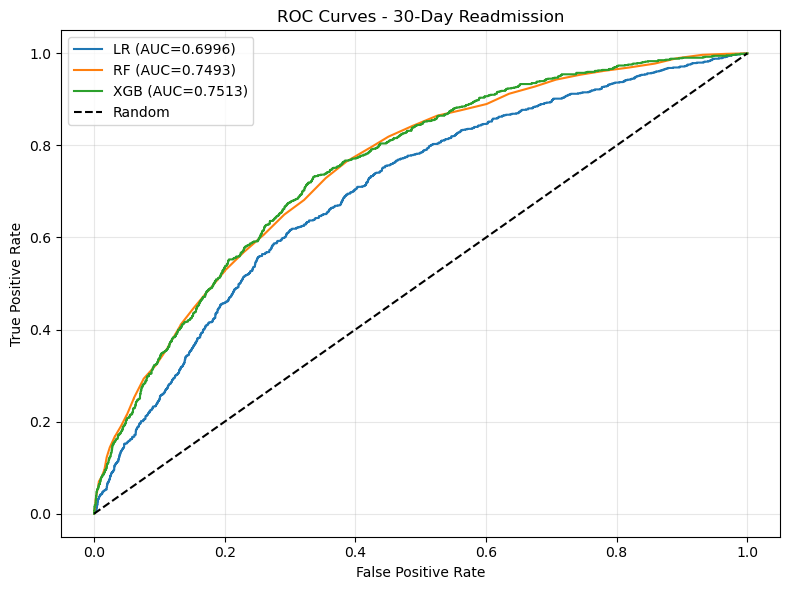

Saved: ../outputs/roc_curves.png


In [39]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, probs in [('LR', lr_probs), ('RF', rf_probs), ('XGB', xgb_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - 30-Day Readmission')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../outputs/roc_curves.png')

## Section 8: Fairness Audit

In [40]:
fd = pd.read_parquet('../outputs/final_dataset_clean.parquet')

print('final_dataset_clean shape:', fd.shape)
print()
print('Head:')
print(fd.head(2))
print()
print('Dtypes (first 10):')
print(fd.dtypes.head(10))
print()
print('All columns:')
print(list(fd.columns))

final_dataset_clean shape: (23881, 455)

Head:
   subject_id   hadm_id  age_at_admission  los_days  came_via_ed  \
0    10014765  29840268                71         1            1   
1    10014765  26650343                77         5            1   

   prior_admissions_count  readmitted_30d  10     100    101    ...  \
0                       0               0      0      0      1  ...   
1                       1               0      0      0      1  ...   

   marital_status_SINGLE  marital_status_WIDOWED  race_ASIAN  race_BLACK  \
0                  False                   False       False       False   
1                  False                   False       False       False   

   race_HISPANIC  race_OTHER  race_UNKNOWN  race_WHITE  gender_F  gender_M  
0          False       False         False        True     False      True  
1          False       False         False        True     False      True  

[2 rows x 455 columns]

Dtypes (first 10):
subject_id                int6

In [41]:
# Reconstruct raw categorical demographic columns from OHE if raw columns are absent.
# The source data was one-hot encoded before saving, so race/gender/insurance are stored
# as individual binary columns (e.g. race_WHITE, gender_F, insurance_Medicare).
for demo in ['race', 'gender', 'insurance']:
    if demo in fd.columns:
        print(f'Column "{demo}" found directly.')
    else:
        ohe_cols = [c for c in fd.columns if c.startswith(demo + '_')]
        if ohe_cols:
            print(f'Column "{demo}" not found. Reconstructing from OHE columns: {ohe_cols}')
            fd[demo] = fd[ohe_cols].idxmax(axis=1).str.replace(demo + '_', '', regex=False)
        else:
            print(f'WARNING: Column "{demo}" not found and no OHE columns detected. Skipping.')

print()
print('Demographic column check complete.')

Column "race" not found. Reconstructing from OHE columns: ['race_ASIAN', 'race_BLACK', 'race_HISPANIC', 'race_OTHER', 'race_UNKNOWN', 'race_WHITE']
Column "gender" not found. Reconstructing from OHE columns: ['gender_F', 'gender_M']
Column "insurance" not found. Reconstructing from OHE columns: ['insurance_missing', 'insurance_Medicaid', 'insurance_Medicare', 'insurance_No charge', 'insurance_Other', 'insurance_Private']

Demographic column check complete.


In [42]:
# Align test set to demographics using shared integer index.
# X_test.index holds the original row positions from final_dataset_clean.
test_idx = X_test.index

if test_idx.isin(fd.index).all():
    fd_test = fd.loc[test_idx].copy()
    fd_test['y_true'] = y_test.values
    fd_test['y_prob'] = best_probs
    print(f'Aligned {len(fd_test)} test rows to demographics.')
else:
    print('WARNING: Test set indices do not align with final_dataset_clean indices. Skipping fairness audit.')
    fd_test = None

all_fairness = []

if fd_test is not None:
    for demo in ['race', 'gender', 'insurance']:
        if demo not in fd_test.columns:
            print(f'WARNING: Column "{demo}" not available in test demographics. Skipping.')
            continue

        print(f'\nFairness audit: {demo}')
        rows = []
        for grp_val, grp_df in fd_test.groupby(demo):
            n = len(grp_df)
            readmit_rate = grp_df['y_true'].mean()
            if grp_df['y_true'].nunique() < 2:
                auc_val = float('nan')
            else:
                auc_val = roc_auc_score(grp_df['y_true'], grp_df['y_prob'])
            rows.append({
                'Demographic': demo,
                'Group': grp_val,
                'N': n,
                'Readmission_Rate': round(readmit_rate, 4),
                'ROC_AUC': round(auc_val, 4) if not np.isnan(auc_val) else float('nan'),
            })

        grp_out = pd.DataFrame(rows)
        print(grp_out.to_string(index=False))
        all_fairness.append(grp_out)

if all_fairness:
    fairness_df = pd.concat(all_fairness, ignore_index=True)
    fairness_df.to_csv('../outputs/fairness_audit.csv', index=False)
    print('\nSaved: ../outputs/fairness_audit.csv')
else:
    print('No fairness data to save.')

Aligned 4771 test rows to demographics.

Fairness audit: race
Demographic    Group    N  Readmission_Rate  ROC_AUC
       race    ASIAN  147            0.1429   0.6236
       race    BLACK  818            0.2127   0.7788
       race HISPANIC  308            0.2045   0.7803
       race    OTHER  308            0.1753   0.7363
       race  UNKNOWN   55            0.1091   0.6514
       race    WHITE 3135            0.2000   0.7476

Fairness audit: gender
Demographic Group    N  Readmission_Rate  ROC_AUC
     gender     F 2304            0.1923   0.7674
     gender     M 2467            0.2035   0.7366

Fairness audit: insurance
Demographic     Group    N  Readmission_Rate  ROC_AUC
  insurance  Medicaid  889            0.2013   0.7512
  insurance  Medicare 2136            0.1976   0.7535
  insurance No charge    4            0.0000      NaN
  insurance     Other  145            0.1931   0.6828
  insurance   Private 1521            0.2005   0.7547
  insurance   missing   76            0.14

## Section 9: Save Best Model Metadata

In [43]:
metadata = {
    'model_name': best_model_name,
    'roc_auc': float(best_model_auc),
    'train_shape': list(X_train.shape),
    'test_shape': list(X_test.shape),
    'run_date': datetime.today().strftime('%Y-%m-%d'),
}

with open('../outputs/best_model_info.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: ../outputs/best_model_info.json')
print(json.dumps(metadata, indent=2))

Saved: ../outputs/best_model_info.json
{
  "model_name": "XGB",
  "roc_auc": 0.7513,
  "train_shape": [
    19110,
    452
  ],
  "test_shape": [
    4771,
    452
  ],
  "run_date": "2026-05-12"
}


## Section 10: Summary

In [44]:
print('=' * 60)
print('MODELING SUMMARY')
print('=' * 60)
print(f'Best model: {best_model_name}, ROC-AUC: {best_model_auc:.4f}')
print()
print('Files saved:')
print('  ../outputs/lr_model.pkl')
print('  ../outputs/rf_model.pkl')
print('  ../outputs/xgb_model.pkl')
print('  ../outputs/calibration_curves.png')
print('  ../outputs/roc_curves.png')
print('  ../outputs/fairness_audit.csv')
print('  ../outputs/best_model_info.json')
print()
print('Next step: SHAP explainability on best model')
print()
print('Reminder: Update Readme.txt with modeling results and date.')

MODELING SUMMARY
Best model: XGB, ROC-AUC: 0.7513

Files saved:
  ../outputs/lr_model.pkl
  ../outputs/rf_model.pkl
  ../outputs/xgb_model.pkl
  ../outputs/calibration_curves.png
  ../outputs/roc_curves.png
  ../outputs/fairness_audit.csv
  ../outputs/best_model_info.json

Next step: SHAP explainability on best model

Reminder: Update Readme.txt with modeling results and date.


## Section 11: Plots

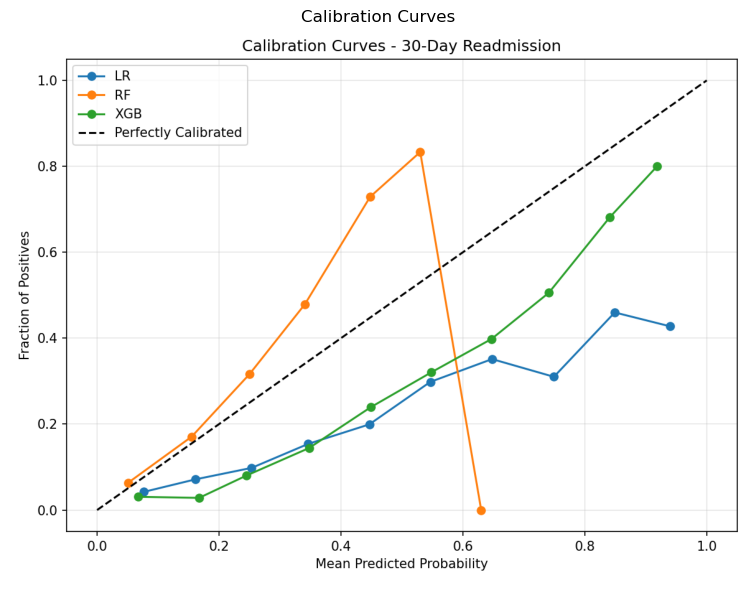

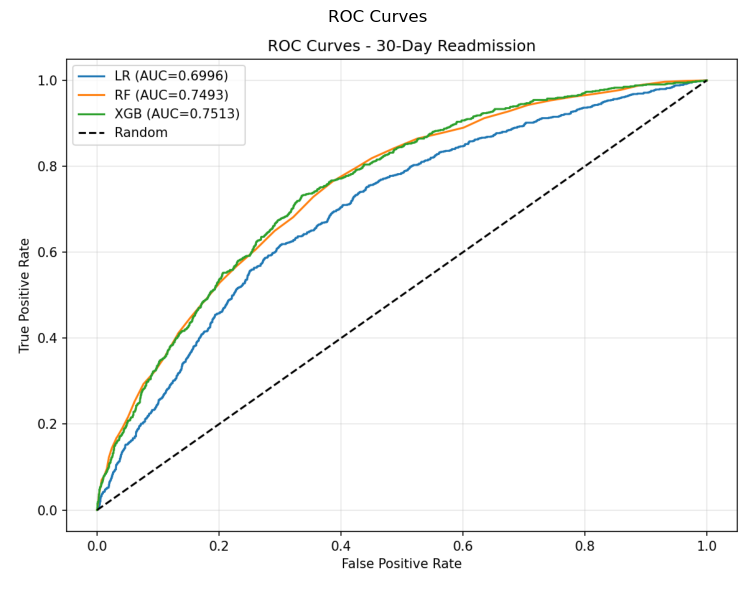


Model Comparison Summary:
  Model  ROC_AUC  Accuracy  Precision  Recall      F1
0    LR   0.6996    0.7017     0.3460  0.5683  0.4301
1    RF   0.7493    0.8026     0.7143  0.0053  0.0105
2   XGB   0.7513    0.7426     0.3934  0.5524  0.4595


In [45]:
# Section 11: Visualization Gallery

from PIL import Image
import os

# Display calibration curves
if os.path.exists('../outputs/calibration_curves.png'):
    img = Image.open('../outputs/calibration_curves.png')
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Calibration Curves')
    plt.tight_layout()
    plt.show()
else:
    print('calibration_curves.png not found')

# Display ROC curves
if os.path.exists('../outputs/roc_curves.png'):
    img = Image.open('../outputs/roc_curves.png')
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('ROC Curves')
    plt.tight_layout()
    plt.show()
else:
    print('roc_curves.png not found')

# Display model comparison table
print('\nModel Comparison Summary:')
if 'comparison_df' in locals():
    print(comparison_df)
else:
    print('Model comparison table not found. Checking available variables...')